# PROG8431 - Group Assignment 1
**Team Members:**
1. Sukhchain Singh (ID: 9111541)
2. Preethi (ID: 87654321)
3. Arya (ID: 45678912)

## What is Our Project About?

Imagine you own a big shopping mall. Every day, different people walk through the doors. Some visitors have high-paying jobs and lots of money in the bank, while others have smaller budgets. But here is the interesting secret: having a lot of money doesn't mean a person will spend a lot of money in your store!

In this project, we are studying 200 real shoppers to look at two simple numbers:
1. **Annual Income:** How much money they earn each year.
2. **Spending Score:** How much they actually spend in the mall.

Our goal is to see who our most loyal spenders are so the mall can send them special sales deals and discount coupons!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib_venn import venn2

# Ensure plots show directly in the notebook
%matplotlib inline

## Load and cleansing Data : 
We will load and cleanse our data below.

In [6]:


# Load the actual CSV file downloaded from Kaggle
df = pd.read_csv('../data/Mall_Customers.csv')

# Data Cleansing Steps:
# 1. Remove spaces and special charactersfrom Column names for easier access.

df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('$', '')

# 2. Rename columns for clarity

df.rename(columns={
    'Annual_Income_k': 'Annual_Income_CAD(*1000)',
    'Spending_Score_1-100': 'Spending_Score'
}, inplace=True)

# 3. Check and drop any duplicate rows

df.drop_duplicates(inplace=True)

# 4. Fill missing values if any exist (e.g. fill numeric gaps with column median)
df['Annual_Income_CAD(*1000)'] = df['Annual_Income_CAD(*1000)'].fillna(df['Annual_Income_CAD(*1000)'].median())

print("Data successfully loaded and cleaned:")
print(df.head(10))

Data successfully loaded and cleaned:
   CustomerID  Gender  Age  Annual_Income_CAD(*1000)  Spending_Score
0           1    Male   19                        15              39
1           2    Male   21                        15              81
2           3  Female   20                        16               6
3           4  Female   23                        16              77
4           5  Female   31                        17              40
5           6  Female   22                        17              76
6           7  Female   35                        18               6
7           8  Female   23                        18              94
8           9    Male   64                        19               3
9          10  Female   30                        19              72


### 50-Word Use Case Summary
This project looks at how a customer's yearly income affects how much they spend at a shopping mall. By grouping shoppers based on these habits, store managers can understand their audience better. This helps businesses create smarter marketing campaigns, keep their best customers coming back, and increase overall sales.

## Object Oriented Analysis Class



--- Stats for Annual_Income_CAD(*1000) ---


'Mean (Average):           60.56'

'Median (Middle):          61.50'

'Mode (Most Frequent):     54.00'

'Variance:                 689.84'

...

'Quartile 2 (50%):         50.00'

'Quartile 3 (75%):         73.00'

'Quartile 4 (100%):        99.00'



--- NUMERICAL SUMMARY OF ALL NUMERIC COLUMNS ---


,Age,Annual_Income_CAD(*1000),Spending_Score
count,200.00,200.00,200.00
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
25%,28.75,41.50,34.75
50%,36.00,61.50,50.00
75%,49.00,78.00,73.00
max,70.00,137.00,99.00


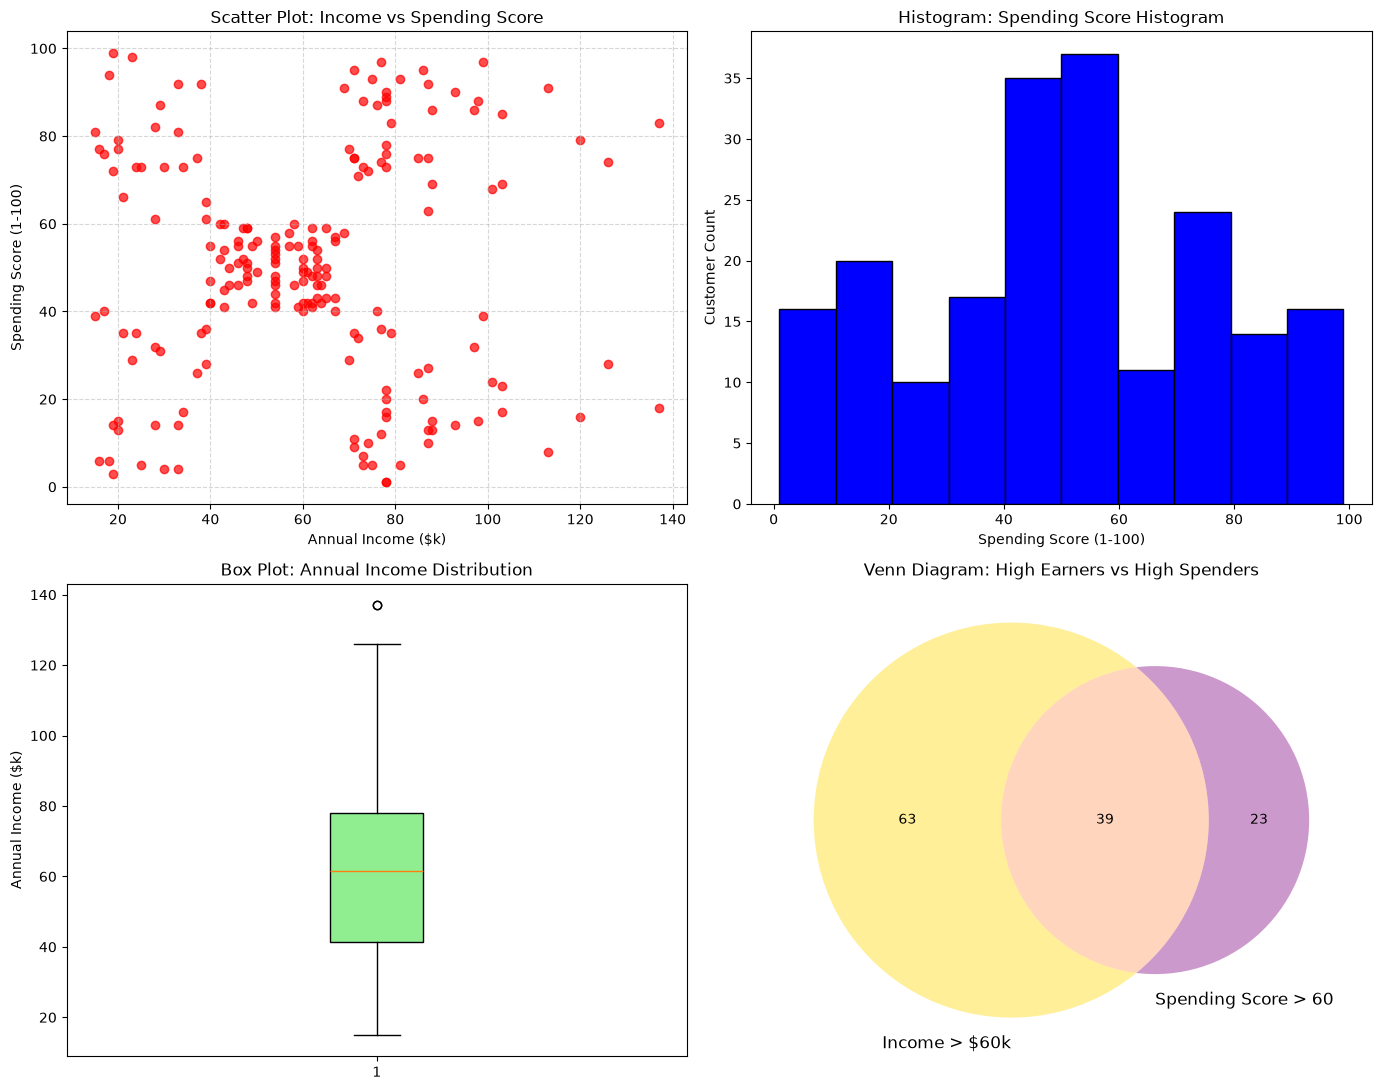

In [13]:
class MallData:
    # this class holds all our math and plotting functions
    
    def __init__(self, data):
        self.df = data

    def calculate_center_and_spread(self, column):
        #Calculates Mean, Median, Mode, Variance, Std Dev, and 4 Quartiles
        series = self.df[column]
        
        print(f"--- Stats for {column} ---")
        display(f"Mean (Average):           {series.mean():.2f}")
        display(f"Median (Middle):          {series.median():.2f}")
        display(f"Mode (Most Frequent):     {series.mode()[0]:.2f}")
        display(f"Variance:                 {series.var():.2f}")
        display(f"Standard Deviation:       {series.std():.2f}")
        display(f"Quartile 1 (25%):         {series.quantile(0.25):.2f}")
        display(f"Quartile 2 (50%):         {series.quantile(0.50):.2f}")
        display(f"Quartile 3 (75%):         {series.quantile(0.75):.2f}")
        display(f"Quartile 4 (100%):        {series.quantile(1.00):.2f}")

    def display_numerical_summary(self):
        """Presents summary statistics table"""
        print("--- NUMERICAL SUMMARY OF ALL NUMERIC COLUMNS ---")
        display(self.df[['Age', 'Annual_Income_CAD(*1000)', 'Spending_Score']].describe().round(2))

    def plot_all_visualizations(self):
        """Generates Scatter plot, Histogram, Box plot, and Venn diagram"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 11))

        # 1. Scatter Plot (Income vs Spending Score)
        axes[0, 0].scatter(self.df['Annual_Income_CAD(*1000)'], self.df['Spending_Score'], color='red', alpha=0.7)
        axes[0, 0].set_title('Scatter Plot: Income vs Spending Score')
        axes[0, 0].set_xlabel('Annual Income ($k)')
        axes[0, 0].set_ylabel('Spending Score (1-100)')
        axes[0, 0].grid(True, linestyle='--', alpha=0.5)

        # 2. Histogram (Distribution of Spending Score)
        axes[0, 1].hist(self.df['Spending_Score'], bins=10, color='blue', edgecolor='black')
        axes[0, 1].set_title('Histogram: Spending Score Histogram')
        axes[0, 1].set_xlabel('Spending Score (1-100)')
        axes[0, 1].set_ylabel('Customer Count')

        # 3. Box-Whisker Plot (Annual Income Spread)
        axes[1, 0].boxplot(self.df['Annual_Income_CAD(*1000)'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
        axes[1, 0].set_title('Box Plot: Annual Income Distribution')
        axes[1, 0].set_ylabel('Annual Income ($k)')

        # 4. Venn Diagram (High Earners vs High Spenders)
        high_income = set(self.df[self.df['Annual_Income_CAD(*1000)'] > 60].index)
        high_spending = set(self.df[self.df['Spending_Score'] > 60].index)

        venn2([high_income, high_spending], 
              set_labels=('Income > $60k', 'Spending Score > 60'), 
              ax=axes[1, 1],
              set_colors=('gold', 'purple'),)
        axes[1, 1].set_title('Venn Diagram: High Earners vs High Spenders')

        plt.tight_layout()
        plt.show()

# Run the analyzer
analyzer = MallData(df)
print("\n")
analyzer.calculate_center_and_spread('Annual_Income_CAD(*1000)')
print("\n")
analyzer.calculate_center_and_spread('Spending_Score')
print("\n")
analyzer.display_numerical_summary()
print("\n")
analyzer.plot_all_visualizations()

## 1-Minute Data Findings (Presentation Script)
So, what did the data actually tell us? 

After running the math on our 200 mall customers, we found that the average shopper makes about $60,000 a year and has a middle-of-the-road spending score. 

However, if you look at the Scatter Plot, you can see the shoppers naturally split into distinct clusters. The most valuable insight comes from our Venn Diagram: it clearly isolates our "VIP" group—the specific customers who have both a high income *and* a high spending score. Because we cleaned and grouped this data, we no longer have to guess who our best customers are; we have the exact numbers to prove it.